--- Model Performance ---
R² Score: 0.468 (Explains 46.8% of the variance)
RMSE: 0.602
Optimal Regularization (Alpha): 10.0

--- Feature Importance (Impact on Crime Rate) ---
                      Feature  Coefficient
5         mean_dist_education     0.147079
6     mean_dist_culture_sport    -0.009014
7  mean_dist_emergency_health    -0.070884
3          mean_dist_mobility    -0.077852
1       light_density_per_km2    -0.078701
8                  population    -0.126157
4            mean_dist_retail    -0.135001
0        tree_density_per_km2    -0.145927
2         mean_dist_nightlife    -0.190312


/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_43992/747557474.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


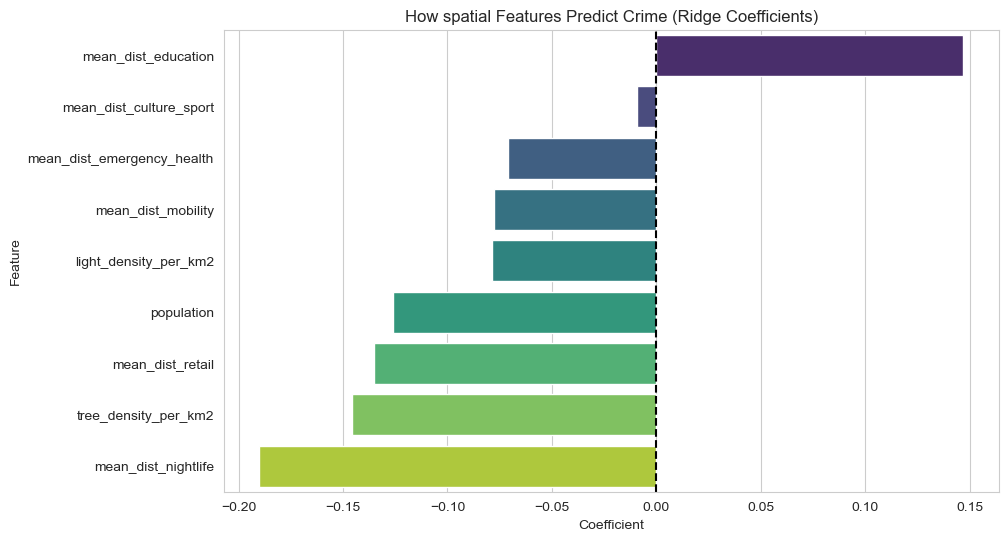

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('data/df_final_model.csv')

features = [
    'tree_density_per_km2',
    'light_density_per_km2',
    'mean_dist_nightlife',
    'mean_dist_mobility',
    'mean_dist_retail',
    'mean_dist_education',
    'mean_dist_culture_sport',
    'mean_dist_emergency_health',
    'population'
]

target = 'log_crime_rate'

#Preprocessing
# Drop missing values to ensure clean modeling
df_model = df.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Ridge Regression with Cross-Validation
# RidgeCV automatically finds the best alpha (regularization strength)
ridge = RidgeCV(alphas=np.logspace(-6, 6, 13))
ridge.fit(X_train_scaled, y_train)

# Evaluation
y_pred = ridge.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance ---")
print(f"R² Score: {r2:.3f} (Explains {r2*100:.1f}% of the variance)")
print(f"RMSE: {rmse:.3f}")
print(f"Optimal Regularization (Alpha): {ridge.alpha_}")

# Interpret Coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Feature Importance (Impact on Crime Rate) ---")
print(coef_df)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.axvline(0, color='black', linestyle='--')
plt.title('How spatial Features Predict Crime (Ridge Coefficients)')
plt.show()

/Users/yoran/miniconda3/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'wijken_en_gemeenten.gpkg': 'wijken' (default), 'gemeenten'. Specify layer parameter to avoid this warning.
  result = read_func(


Moran's I: 0.270
P-value: 0.001
Result: Significant Clustering (The model missed a spatial pattern)


/var/folders/04/yj5x8lbx49sc1jbf3gyzwr3h0000gn/T/ipykernel_43992/259378182.py:48: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_model)
/Users/yoran/miniconda3/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


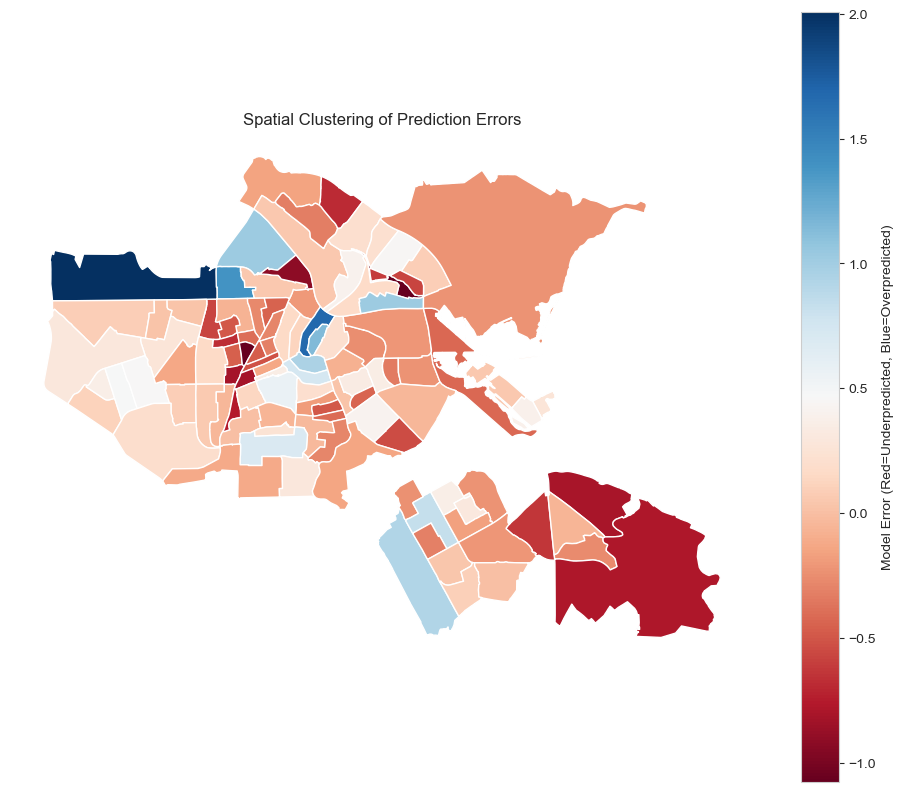

In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from esda.moran import Moran
from libpysal.weights import Queen

# 1. Load your Data
df = pd.read_csv('data/df_final_model.csv')

# 2. Load the Map (Filter for Amsterdam to avoid duplicates)
gdf_all = gpd.read_file("data/wijken_en_gemeenten.gpkg")
gdf_ams = gdf_all[gdf_all['gemeentenaam'] == 'Amsterdam'].copy()

# 3. Merge Data with Map (Using the matching codes we verified)
# 'wijkcode' from GPKG matches 'neighbourhood_code' from CSV
gdf_merged = gdf_ams.merge(df, left_on='wijkcode', right_on='neighbourhood_code')

# --- RE-RUNNING THE MODEL TO GET RESIDUALS ---

# 4. Prepare Ridge Regression
features = ['tree_density_per_km2', 'light_density_per_km2', 'mean_dist_nightlife',
            'mean_dist_mobility', 'mean_dist_retail', 'mean_dist_education',
            'mean_dist_culture_sport', 'mean_dist_emergency_health', 'population']
target = 'log_crime_rate'

# Drop missing values
gdf_model = gdf_merged.dropna(subset=features + [target])

# Scale and Fit
scaler = StandardScaler()
X = gdf_model[features]
y = gdf_model[target]
X_scaled = scaler.fit_transform(X)

ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]) # Simplified alpha list
ridge.fit(X_scaled, y)

# 5. Calculate Residuals (Errors)
gdf_model['predicted'] = ridge.predict(X_scaled)
gdf_model['residual'] = gdf_model[target] - gdf_model['predicted']

# --- SPATIAL ANALYSIS (MORAN'S I) ---

# 6. Create Spatial Weights (Who is next to whom?)
w = Queen.from_dataframe(gdf_model)
w.transform = 'r'

# 7. Calculate Moran's I on the Residuals
mi = Moran(gdf_model['residual'], w)

print(f"Moran's I: {mi.I:.3f}")
print(f"P-value: {mi.p_sim:.3f}")

if mi.p_sim < 0.05:
    print("Result: Significant Clustering (The model missed a spatial pattern)")
else:
    print("Result: Random Errors (The model works well spatially!)")

# 8. Plot the Map of Residuals
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_model.plot(column='residual', cmap='RdBu', legend=True, ax=ax,
               legend_kwds={'label': "Model Error (Red=Underpredicted, Blue=Overpredicted)"})
ax.set_title('Spatial Clustering of Prediction Errors')
ax.axis('off')
plt.show()